# Word Co-occurrence Analysis
Sliding-window co-occurrence on r/BPD and r/BPDlovedones FP posts.
Stopwords match those in `Code.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter, defaultdict
from itertools import combinations

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Stopwords & preprocessing
Copied verbatim from `Code.ipynb` so tokenisation is identical.

In [2]:
STOPWORDS = set(stopwords.words('english'))
CUSTOM_STOP = {
    # search query terms
    'fp', 'favorite', 'favourite', 'person', 'people', 'bpd', 'borderline', 'personality', 'disorder', 'pwbpd',
    # high-frequency low-signal fillers
    'like', 'know', 'really', 'want', 'get', 'would', 'cant', 'wont', 'didnt', 'isnt', 'wasnt', 'havent', 'hadnt',
    'just', 'one', 'also', 'even', 'felt', 'could', 'feel', 'think', 'make', 'see', 'go', 'going', 'said',
    'im', 'ive', 'dont', 'doesnt', 'its', 'thats', 'youre', 'theyre',
    # generic conversational filler
    'say', 'tell', 'told', 'ask', 'asked', 'saying', 'got', 'friends',
    'still', 'much', 'lot', 'something', 'someone', 'anyone', 'everyone',
    'thing', 'things', 'way', 'back', 'always', 'never', 'ever',
    'now', 'time', 'day', 'days', 'well', 'new',
    'little', 'big', 'used', 'trying', 'try',
    # contractions / fragments
    'theyll', 'theyd', 'theyve', 'whats', 'theres', 'heres',
    'ill', 'wed', 'weve', 'youll', 'youd', 'youve',
    'put', 'got', 'say', 'said',
    # vague quantifiers
    'many', 'more', 'most', 'very', 'too', 'enough', 'every',
    'few', 'less', 'bit', 'sort', 'made', 'else', 'since', 'started', 'thought', 'feeling', 'feels',
    # generic action verbs
    'happened', 'happen', 'happens', 'came', 'come',
    'took', 'take', 'found', 'find', 'keep', 'kept', 'set', 'let',
    'stopped', 'stop', 'gave', 'give', 'given',
    'seen', 'looked', 'look', 'turned', 'turn', 'done', 'doing', 'right',
    # cognitive verbs without valence
    'realize', 'realized', 'notice', 'noticed', 'remember', 'remembered',
    'forgot', 'forget', 'understood', 'understand', 'knew', 'figure',
    # time / frequency
    'year', 'years', 'month', 'months', 'week', 'weeks', 'ago',
    'today', 'yesterday', 'recently', 'last', 'first', 'next', 'past',
    # hedging adverbs
    'actually', 'basically', 'literally', 'tbh', 'honestly',
    'pretty', 'quite', 'probably', 'maybe', 'usually', 'sometimes',
    'often', 'already', 'almost', 'though', 'although',
    # generic nouns
    'stuff', 'situation', 'reason', 'point', 'post', 'comment',
    'account', 'part', 'place', 'number', 'times', 'removed', 'went', 'getting', 'makes', 'sure',
    # reddit meta-language (survive punctuation stripping)
    'deleted', 'edit', 'edited', 'reddit', 'subreddit', 'mod', 'mods', 'bot', 'karma',
    'upvote', 'downvote', 'oc',
    # high-frequency vague terms
    'need', 'help', 'okay', 'ok', 'yeah', 'yep', 'nope',
    # generic modifiers and state-change verbs
    'mean', 'means', 'whole', 'entire', 'long', 'short', 'different', 'same',
    'become', 'became', 'type', 'kind',
}
STOPWORDS |= CUSTOM_STOP

def preprocess(text: str) -> list:
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

## Load data

In [3]:
bpd   = pd.read_csv('data/bpd_fp_posts.csv')
loved = pd.read_csv('data/bpdlovedones_fp_posts.csv')
df = pd.concat([bpd, loved], ignore_index=True)
df = df.drop_duplicates(subset='id')

df['text_combined'] = (
    df['title'].fillna('') + ' ' + df['text'].fillna('')
).str.strip()

df = df[df['text_combined'].str.len() > 10].copy()
df = df.dropna(subset=['year'])
df['year'] = df['year'].astype(int)

print(f'{len(df):,} posts  |  years {df.year.min()}–{df.year.max()}')
print(df['subreddit'].value_counts().to_string())

86,145 posts  |  years 2016–2025
subreddit
BPD             81958
BPDlovedones     4187


## Co-occurrence builder
`build_cooccurrence` uses a sliding token window: for each token at position *i*, it pairs it with every token within `window` steps ahead. Pairs are stored as sorted tuples so `(a, b)` and `(b, a)` collapse into one key.

In [4]:
def build_cooccurrence(texts, window: int = 5) -> Counter:
    """Return Counter of (word_a, word_b) → count using a sliding window."""
    cooc = Counter()
    for text in texts:
        tokens = preprocess(text)
        for i, word in enumerate(tokens):
            for other in tokens[i + 1 : i + 1 + window]:
                if other != word:
                    cooc[tuple(sorted((word, other)))] += 1
    return cooc


def cooc_to_df(cooc: Counter, top_n: int = 100) -> pd.DataFrame:
    rows = [(a, b, c) for (a, b), c in cooc.most_common(top_n)]
    return pd.DataFrame(rows, columns=['word1', 'word2', 'count'])

## Parameters — edit here to slice the corpus

In [5]:
SUBREDDIT  = 'BPD'          # 'BPD', 'BPDlovedones', or None for both
YEAR_RANGE = (2016, 2025)   # (start, end) inclusive, or None for all years
WINDOW     = 5              # sliding-window size (tokens)
TOP_N      = 50             # pairs to surface in tables / graph

# ── filter ────────────────────────────────────────────────────────────────────
subset = df.copy()
if SUBREDDIT:
    subset = subset[subset['subreddit'] == SUBREDDIT]
if YEAR_RANGE:
    subset = subset[
        (subset['year'] >= YEAR_RANGE[0]) & (subset['year'] <= YEAR_RANGE[1])
    ]

print(f'Corpus slice: {len(subset):,} posts')

cooc = build_cooccurrence(subset['text_combined'], window=WINDOW)
print(f'Unique pairs:  {len(cooc):,}')

Corpus slice: 81,958 posts
Unique pairs:  5,099,374


## Top co-occurring pairs

In [6]:
pairs_df = cooc_to_df(cooc, top_n=TOP_N)
pairs_df

,word1,word2,count
0,best,friend,8927
1,health,mental,3956
2,life,love,2949
3,love,relationship,2763
4,harm,self,2235
5,healthy,relationship,2197
6,hate,love,2050
7,life,without,2049
8,media,social,2034
9,life,relationship,1855


## Export for D3 force-directed graph
Writes `data/cooccurrence.json` (current slice) and `data/cooccurrence_by_year.json` (one graph per year, for animated/filtered D3 views).

In [7]:
import json

def to_d3(pairs: pd.DataFrame, top_n: int = TOP_N) -> dict:
    """
    Convert a pairs DataFrame to a D3 force-graph JSON object.
    { nodes: [{id, weight}], links: [{source, target, value}] }
    `weight` on nodes is the sum of all edge values (weighted degree).
    """
    deg = {}
    for _, row in pairs.iterrows():
        deg[row['word1']] = deg.get(row['word1'], 0) + row['count']
        deg[row['word2']] = deg.get(row['word2'], 0) + row['count']

    nodes = [{"id": w, "weight": int(deg[w])} for w in deg]
    links = [
        {"source": row['word1'], "target": row['word2'], "value": int(row['count'])}
        for _, row in pairs.iterrows()
    ]
    return {"nodes": nodes, "links": links}


# ── Single-slice export (matches current SUBREDDIT / YEAR_RANGE / TOP_N) ──────
d3_single = to_d3(pairs_df)
with open("data/cooccurrence.json", "w", encoding="utf-8") as f:
    json.dump(d3_single, f, indent=2)
print(f"Exported data/cooccurrence.json  "
      f"({len(d3_single['nodes'])} nodes, {len(d3_single['links'])} links)")


# ── Per-year export (one graph per year, same subreddit filter) ───────────────
sub_for_export = df[df['subreddit'] == SUBREDDIT] if SUBREDDIT else df

d3_by_year = {}
for yr in sorted(sub_for_export['year'].unique()):
    yr_texts = sub_for_export[sub_for_export['year'] == yr]['text_combined']
    yr_cooc  = build_cooccurrence(yr_texts, window=WINDOW)
    yr_pairs = cooc_to_df(yr_cooc, top_n=TOP_N)
    d3_by_year[str(int(yr))] = to_d3(yr_pairs)

with open("data/cooccurrence_by_year.json", "w", encoding="utf-8") as f:
    json.dump(d3_by_year, f, indent=2)
print(f"Exported data/cooccurrence_by_year.json  ({len(d3_by_year)} years)")

Exported data/cooccurrence.json  (39 nodes, 50 links)
Exported data/cooccurrence_by_year.json  (10 years)


## Focal-word lookup
Given a word of interest, return its top co-occurring partners ranked by count.

In [8]:
def focal_cooc(word: str, cooc: Counter, n: int = 20) -> pd.DataFrame:
    """Top n words that appear alongside `word` in the co-occurrence counter."""
    results = []
    for (a, b), count in cooc.items():
        if a == word:
            results.append((b, count))
        elif b == word:
            results.append((a, count))
    results.sort(key=lambda x: -x[1])
    return pd.DataFrame(results[:n], columns=['co_word', 'count'])


# ── Edit FOCAL_WORD to explore ─────────────────────────────────────────────
FOCAL_WORD = 'relationship'

focal_df = focal_cooc(FOCAL_WORD, cooc, n=20)
print(f"Top co-occurrences with '{FOCAL_WORD}':")
focal_df

Top co-occurrences with 'relationship':


,co_word,count
0,love,2763
1,healthy,2197
2,life,1855
3,good,1614
4,friend,1597
5,partner,1511
6,best,1414
7,together,1339
8,end,1263
9,work,1230


## Network graph
Top `TOP_N` pairs drawn as a weighted graph. Edge thickness and node size scale with co-occurrence frequency.

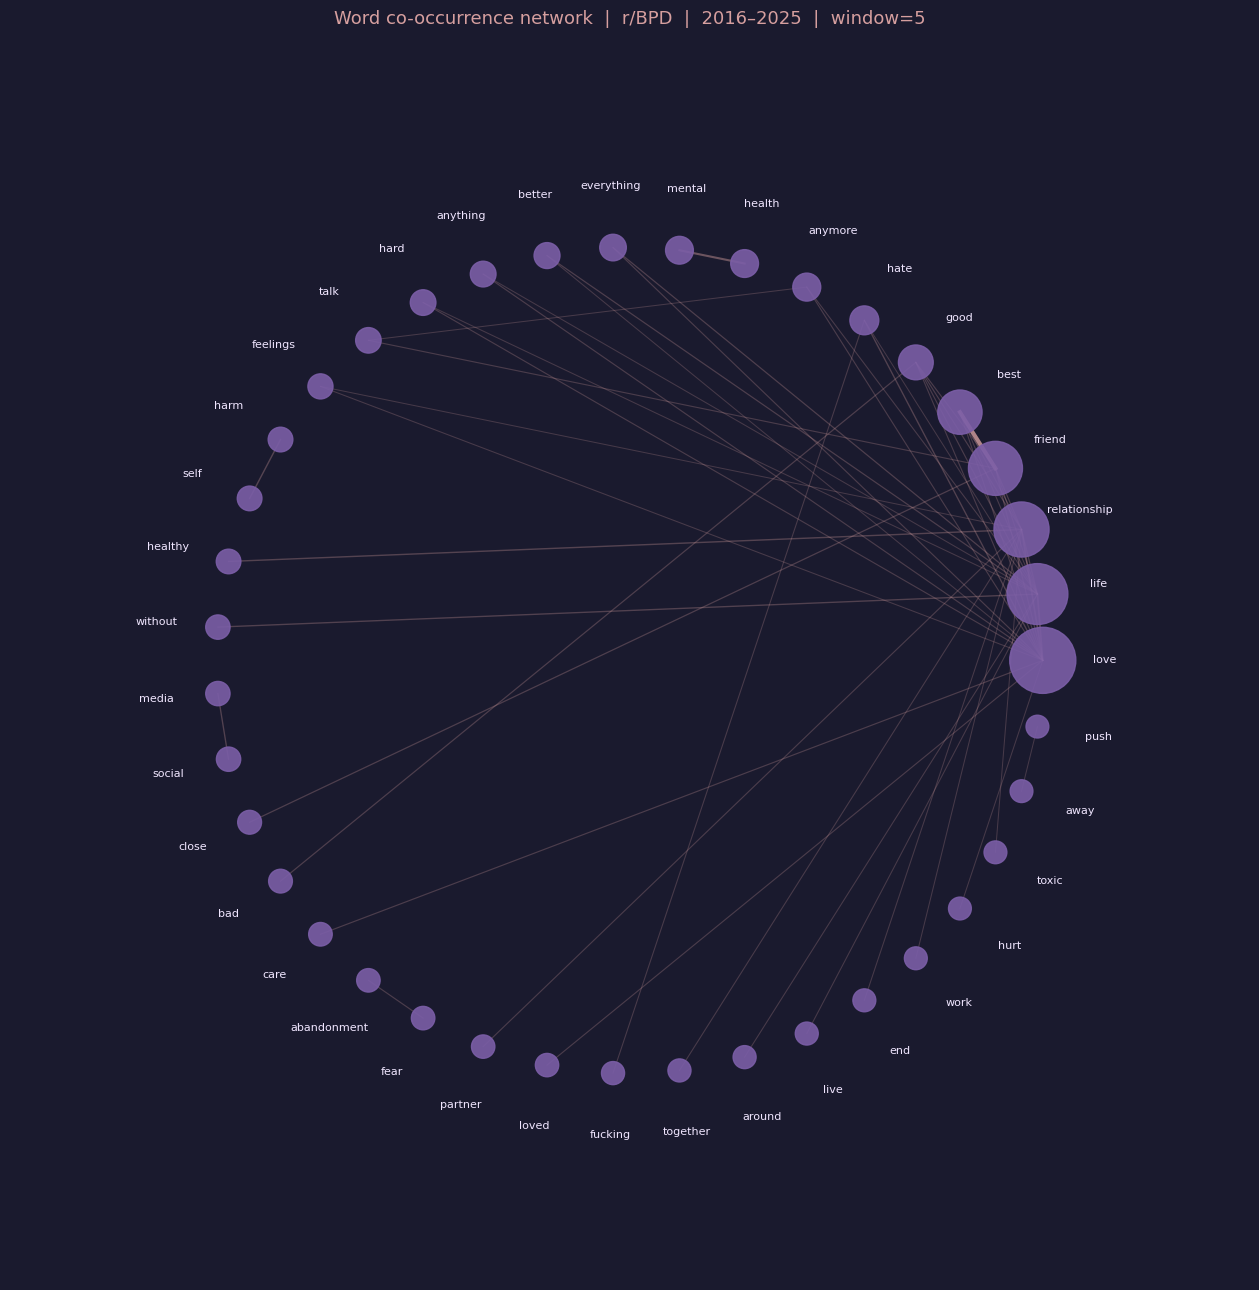

In [9]:
# ── Circular network layout — pure matplotlib, no external graph library ───────
degree = {}
for _, row in pairs_df.iterrows():
    degree[row['word1']] = degree.get(row['word1'], 0) + row['count']
    degree[row['word2']] = degree.get(row['word2'], 0) + row['count']

words  = sorted(degree, key=lambda w: -degree[w])
N      = len(words)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
pos    = {w: (np.cos(a), np.sin(a)) for w, a in zip(words, angles)}

max_count = pairs_df['count'].max()
max_deg   = max(degree.values())

fig, ax = plt.subplots(figsize=(13, 13))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.set_aspect('equal')
ax.axis('off')

# Edges
for _, row in pairs_df.iterrows():
    x1, y1 = pos[row['word1']]
    x2, y2 = pos[row['word2']]
    alpha = 0.15 + 0.65 * row['count'] / max_count
    lw    = 0.4  + 2.5  * row['count'] / max_count
    ax.plot([x1, x2], [y1, y2], color='#d69f9f', alpha=alpha, linewidth=lw, zorder=1)

# Nodes + labels
for w, (x, y) in pos.items():
    r = 0.025 + 0.055 * degree[w] / max_deg
    ax.add_patch(plt.Circle((x, y), r, color='#7b5ea7', zorder=2, alpha=0.9))
    ax.text(x * 1.15, y * 1.15, w,
            ha='center', va='center', fontsize=8, color='#f0e6ff', zorder=3,
            bbox=dict(boxstyle='round,pad=0.1', fc='#1a1a2e', ec='none', alpha=0.5))

sub_label = SUBREDDIT or 'BPD + BPDlovedones'
yr_label  = f'{YEAR_RANGE[0]}–{YEAR_RANGE[1]}' if YEAR_RANGE else 'all years'
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title(
    f'Word co-occurrence network  |  r/{sub_label}  |  {yr_label}  |  window={WINDOW}',
    color='#d69f9f', fontsize=13, pad=12
)
plt.tight_layout()
plt.show()

## Year-over-year shift for a focal word
Tracks how a word's top neighbours evolve across years. Each row is a year; columns are the union of top co-occurring words across all years, with counts as values.

In [10]:
FOCAL_WORD_YOY = 'relationship'   # word to track over time
TOP_PARTNERS   = 10               # how many co-words to compare
SUB_YOY        = 'BPD'           # subreddit for this analysis

yoy_sub = df[df['subreddit'] == SUB_YOY] if SUB_YOY else df
years   = sorted(yoy_sub['year'].unique())

# Build one co-occurrence counter per year
yoy_records = {}
for yr in years:
    yr_texts  = yoy_sub[yoy_sub['year'] == yr]['text_combined']
    yr_cooc   = build_cooccurrence(yr_texts, window=WINDOW)
    yoy_records[yr] = focal_cooc(FOCAL_WORD_YOY, yr_cooc, n=TOP_PARTNERS)

# Combine into a wide DataFrame
all_partners = pd.concat(yoy_records.values())['co_word'].value_counts().head(TOP_PARTNERS).index.tolist()

yoy_wide = pd.DataFrame(index=years, columns=all_partners, dtype=float)
for yr, fdf in yoy_records.items():
    for _, row in fdf.iterrows():
        if row['co_word'] in all_partners:
            yoy_wide.loc[yr, row['co_word']] = row['count']
yoy_wide = yoy_wide.fillna(0)

print(f"Co-occurrence counts for '{FOCAL_WORD_YOY}' by year:")
yoy_wide

Co-occurrence counts for 'relationship' by year:


,love,good,life,healthy,best,friend,together,partner,romantic,work
2016,23.0,18.0,15.0,13.0,0.0,0.0,0.0,0.0,21.0,0.0
2017,67.0,55.0,46.0,0.0,49.0,47.0,39.0,0.0,0.0,0.0
2018,132.0,102.0,101.0,104.0,75.0,80.0,0.0,0.0,71.0,73.0
2019,154.0,149.0,157.0,178.0,116.0,100.0,99.0,0.0,0.0,0.0
2020,253.0,177.0,187.0,296.0,161.0,196.0,0.0,0.0,129.0,137.0
2021,364.0,213.0,253.0,284.0,190.0,187.0,179.0,178.0,0.0,185.0
2022,379.0,266.0,256.0,421.0,224.0,228.0,0.0,241.0,0.0,204.0
2023,347.0,176.0,221.0,275.0,146.0,188.0,153.0,222.0,0.0,0.0
2024,648.0,255.0,362.0,338.0,257.0,338.0,288.0,331.0,0.0,0.0
2025,396.0,203.0,257.0,256.0,187.0,223.0,226.0,267.0,174.0,0.0


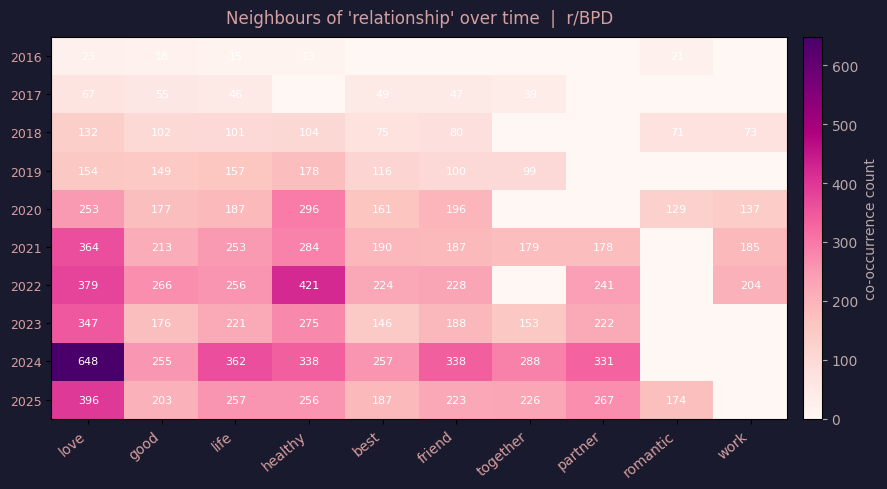

In [11]:
# ── Heatmap of year-over-year co-occurrence counts ────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, len(all_partners) * 0.9), max(5, len(years) * 0.45)))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

data_arr = yoy_wide.values.astype(float)
im = ax.imshow(data_arr, aspect='auto', cmap='RdPu', interpolation='nearest')

ax.set_xticks(range(len(all_partners)))
ax.set_xticklabels(all_partners, rotation=40, ha='right', color='#d69f9f', fontsize=10)
ax.set_yticks(range(len(years)))
ax.set_yticklabels(years, color='#d69f9f', fontsize=9)

for i in range(len(years)):
    for j in range(len(all_partners)):
        val = int(data_arr[i, j])
        ax.text(j, i, str(val) if val else '', ha='center', va='center',
                fontsize=8, color='white')

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.ax.tick_params(colors='#b8a8a8')
cbar.set_label('co-occurrence count', color='#b8a8a8')

ax.set_title(
    f"Neighbours of '{FOCAL_WORD_YOY}' over time  |  r/{SUB_YOY or 'both'}",
    color='#d69f9f', fontsize=12, pad=10
)
plt.tight_layout()
plt.show()